# `dtd-friesz` — Friesz et al.'s (1994) route-based projected dynamical system

**What.** Per-OD route flows evolve by the projected dynamical system ḣ = P_K(h, −c(h)), discretized as h_{k+1} = P_K(h_k − a c(h_k)) — projected gradient descent on Beckmann in ROUTE space (since ∂Z/∂h_p = c_p). Its fixed point is Wardrop UE.

**Why it is in the benchmark.** Its signature is the PDS descent: Beckmann is a Lyapunov function descending to the UE value, the exact per-OD simplex projection keeps flows in Ω every day, and the excess-cost disequilibrium collapses to zero. See the
[model compendium](../../docs/MODELS.md) and the certificate design in
[docs/ARCHITECTURE.md](../../docs/ARCHITECTURE.md) (P1).

**Scope.** Runs the process on a built-in scenario and certifies the result; it does
not benchmark day-to-day models against each other. Reference: Friesz et al. (1994), *Operations Research* 42(6).

**Canon.** `[friesz1994daytoday]`, [docs/REFERENCES.md](../../docs/REFERENCES.md) / [docs/references.bib](../../docs/references.bib).

## How this notebook is graded

**A notebook never claims a number it does not compute in that cell.** Every scored
quantity below is recomputed live by the P1 `Evaluator` from the flows the model
emitted, in the cell where it is claimed. Model self-reports (the per-day gap/residual,
the Lyapunov value) are shown only as provenance and diffed against the certificate,
exactly as the harness treats them ([README](../../README.md), *Certified, not
self-reported*).

In [1]:
# Setup. `dtd-friesz` is a core day-to-day model: a plain `pip install -e .` suffices —
# no optional extra, so no guard cell. The inline backend is Agg-based (headless CI
# renders into the notebook); NEVER matplotlib.use("Agg") in-kernel — it silently
# suppresses inline figure capture.
%matplotlib inline
import numpy as np

from tabench import (
    Budget,
    Evaluator,
    FrieszDTDModel,
    RngBundle,
    Trace,
    braess_scenario,
    viz,
)

## The scenario

The built-in Braess network (4 nodes, 5 links, one OD pair 1→2, demand 6). Scenarios are
frozen and content-hashed (P2) — the hash below is the benchmark instance's identity.

In [2]:
scenario = braess_scenario()
net = scenario.network
print(f"scenario      : {scenario.name}")
print(f"content hash  : {scenario.content_hash()[:16]}…")
print(f"links         : {net.n_links}  (tail→head: "
      + ", ".join(f"{i}->{j}" for i, j in zip(net.init_node, net.term_node)) + ")")
print(f"total demand  : {scenario.demand.total}")
print("task          : Wardrop UE fixed point")

scenario      : braess
content hash  : cf00f411cdccec88…
links         : 5  (tail→head: 1->3, 1->4, 3->4, 3->2, 4->2)
total demand  : 6.0
task          : Wardrop UE fixed point


## Run the adjustment process

The model contract ([CONTRIBUTING.md](../../CONTRIBUTING.md)): a model receives
`(scenario, budget, rng, trace)` and records one checkpoint per day — here a *budget
iteration is a day*. Everything the model writes into `self_report` (the per-day
gap/residual, the Lyapunov value) is provenance, not a score.

In [3]:
bundle_trace = Trace()
model = FrieszDTDModel()
model.solve(scenario, Budget(iterations=800, target_relative_gap=1e-8),
            RngBundle(0), bundle_trace)
final = bundle_trace.final
print(f"model            : {model.name}")
print(f"days simulated   : {final.coords.iterations}  "
      f"({final.coords.sp_calls} shortest-path calls)")
print(f"emitted flows    : {np.round(final.link_flows, 6)}")
print(f"self-reported gap     : {final.self_report['relative_gap']:.3e}  (provenance only)")

model            : dtd-friesz
days simulated   : 30  (31 shortest-path calls)
emitted flows    : [4. 2. 2. 2. 4.]
self-reported gap     : 7.880e-09  (provenance only)


## Certify (P1) — the fixed point AND the descent

The harness, never the model, computes every scored metric. Certified here: (1) the
terminal flows are the Wardrop UE — relative gap → 0 with the analytic Braess anchor
recomputed in-cell; (2) the day-to-day signature — Beckmann descends monotonically to
386 — plus this model's distinctive provenance measure.

In [4]:
evaluator = Evaluator(scenario)
metrics = evaluator.evaluate(final.link_flows)
gap = metrics["relative_gap"]
print(f"certified relative gap : {gap:.3e}")
print(f"feasible               : {metrics['feasible']:.0f}")
assert metrics["feasible"] == 1.0
assert gap < 1e-6
# Analytic Braess UE anchor, recomputed in-cell (flows (4,2,2,2,4), every route costs 92).
ref_flows = np.array([4.0, 2.0, 2.0, 2.0, 4.0])
assert evaluator.evaluate(ref_flows)["relative_gap"] < 1e-6
assert np.allclose(final.link_flows, ref_flows, atol=1e-4)
route_time = metrics["tstt"] / scenario.demand.total
print(f"route time (TSTT/D)    : {route_time:.4f}  (analytic UE: 92)")
assert abs(route_time - 92.0) < 1e-2
# Beckmann is a Lyapunov function: monotone non-increasing to the UE value 386.
beckmann = [s.self_report["beckmann"] for s in bundle_trace]
assert all(beckmann[i] >= beckmann[i + 1] - 1e-9 for i in range(len(beckmann) - 1))
assert abs(beckmann[-1] - 386.0) < 1e-2
print(f"Beckmann descent       : {beckmann[0]:.2f} → {beckmann[-1]:.2f}  (monotone ✓)")
# Honesty diff (P1): the terminal self-reported Beckmann value against the SAME
# quantity the certificate itself computes from final.link_flows -- the Lyapunov
# claim is not backed by self-report alone.
assert np.isclose(beckmann[-1], metrics["beckmann_objective"], atol=1e-6)
# The route-flow excess-cost disequilibrium G(h)=Σ h_p(c_p−u_w) (TSTT−SPTT on the working
# set) is >0 off-equilibrium and collapses to 0 at UE (provenance). The exact per-OD
# simplex projection also keeps the flows in Ω every day (a projected dynamical system).
excess = [s.self_report["excess_cost"] for s in bundle_trace]
assert max(excess) > 1.0 and excess[-1] < 1e-4
print(f"excess-cost G(h)       : {max(excess):.3g} → {excess[-1]:.2e}  (→ 0 at UE)")

certified relative gap : 7.880e-09
feasible               : 1
route time (TSTT/D)    : 92.0000  (analytic UE: 92)
Beckmann descent       : 438.00 → 386.00  (monotone ✓)
excess-cost G(h)       : 48.9 → 4.35e-06  (→ 0 at UE)


## Visualize

Both figures come from `tabench.viz`, the house visualizer — every plotted number is one
certified above. Left/top: the certified terminal link flows on the network. Right/bottom:
the emitted flows against the fixed point recomputed in the certify cell — points on the
`y = x` guide mean the day-to-day process settled on it link-for-link.

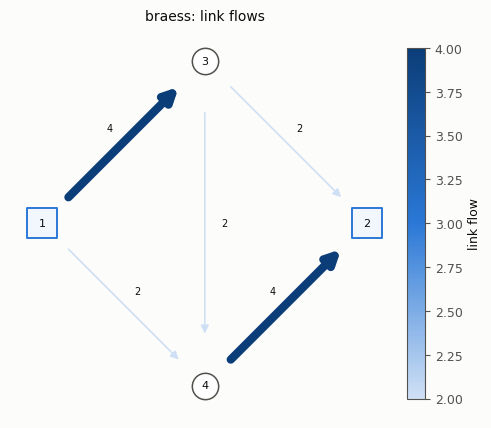

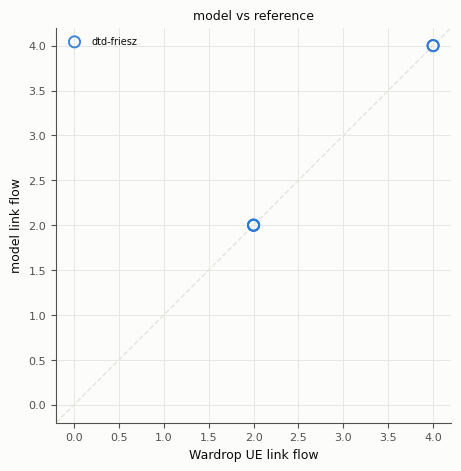

In [5]:
# Certified terminal flows on the network (house style via tabench.viz).
display(viz.plot_network_flows(net, final.link_flows))

# Emitted flows vs the Wardrop UE recomputed above (off-diagonal == not settled).
display(viz.plot_flow_scatter(("Wardrop UE", ref_flows), {"dtd-friesz": final.link_flows}))

## Takeaways & pointers

- **Certified, not self-reported.** The gap came from `Evaluator`; the excess-cost collapse was diffed from the self-report, used only to certify the descent shape.
- **The day-to-day signature is the point.** A UE/SUE *solver* gives you the fixed
  point; a day-to-day *model* gives you the adjustment path to it.
- **Where next.** the route-swap [`dtd-swap`](01-dtd-swap.ipynb) and link-space [`dtd-link`](03-dtd-link.ipynb) paradigms — all three reach the identical certified UE; the lineage in the
  [model compendium](../../docs/MODELS.md).